# Foundation Models / LLMs 

In [13]:
import os
import sys


IS_COLAB = 'google.colab' in sys.modules or 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    print('Running on Colab')
    from google.colab import drive
    drive.mount('/content/drive')
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'transformers', 'accelerate'], check=True)
else:
    print('Running locally')

Running on Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 — Imports & constants

In [ ]:
import os

import numpy as np
import pandas as pd
import torch

from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer


VAR_META = {
    'Albumin':    ('Albumin',                'g/dL'),
    'ALP':        ('ALP',                    'IU/L'),
    'ALT':        ('ALT',                    'IU/L'),
    'AST':        ('AST',                    'IU/L'),
    'Bilirubin':  ('Bilirubin',              'mg/dL'),
    'BUN':        ('BUN',                    'mg/dL'),
    'Cholesterol':('Cholesterol',            'mg/dL'),
    'Creatinine': ('Creatinine',             'mg/dL'),
    'DiasABP':    ('Diastolic BP (inv.)',     'mmHg'),
    'FiO2':       ('FiO2',                   'fraction'),
    'GCS':        ('GCS',                    '3-15'),
    'Glucose':    ('Glucose',                'mg/dL'),
    'HCO3':       ('Bicarbonate',            'mmol/L'),
    'HCT':        ('Hematocrit',             '%'),
    'HR':         ('Heart rate',             'bpm'),
    'K':          ('Potassium',              'mEq/L'),
    'Lactate':    ('Lactate',                'mmol/L'),
    'Mg':         ('Magnesium',              'mmol/L'),
    'MAP':        ('MAP (inv.)',              'mmHg'),
    'MechVent':   ('Mech. ventilation',      '0=off/1=on'),
    'Na':         ('Sodium',                 'mEq/L'),
    'NIDiasABP':  ('Diastolic BP (non-inv.)', 'mmHg'),
    'NIMAP':      ('MAP (non-inv.)',          'mmHg'),
    'NISysABP':   ('Systolic BP (non-inv.)',  'mmHg'),
    'PaCO2':      ('PaCO2',                  'mmHg'),
    'PaO2':       ('PaO2',                   'mmHg'),
    'pH':         ('pH',                     ''),
    'Platelets':  ('Platelets',              'cells/nL'),
    'RespRate':   ('Resp. rate',             'bpm'),
    'SaO2':       ('O2 saturation',          '%'),
    'SysABP':     ('Systolic BP (inv.)',      'mmHg'),
    'Temp':       ('Temperature',            '°C'),
    'TroponinI':  ('Troponin-I',             'μg/L'),
    'TroponinT':  ('Troponin-T',             'μg/L'),
    'Urine':      ('Urine output',           'mL'),
    'WBC':        ('WBC',                    'cells/nL'),
}

DATA_DIR = (
    './drive/MyDrive/data'
    if IS_COLAB else
    '/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/data'
)
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'DATA_DIR : {DATA_DIR}')
print(f'Device   : {DEVICE}')
print(f'Model    : {MODEL_NAME}')
print(f'Variables: {len(VAR_META)}')

DATA_DIR : ./drive/MyDrive/data
Device   : cuda
Model    : Qwen/Qwen2.5-7B-Instruct
Variables: 36


## 2 — Load non-imputed parquet files

In [15]:
df_a_vec = pd.read_parquet(os.path.join(DATA_DIR, 'set_a_raw_vector_not_imputed.parquet'))
df_b_vec = pd.read_parquet(os.path.join(DATA_DIR, 'set_b_raw_vector_not_imputed.parquet'))
df_c_vec = pd.read_parquet(os.path.join(DATA_DIR, 'set_c_raw_vector_not_imputed.parquet'))

print(f'set-a : {df_a_vec.shape}  — {df_a_vec["in_hospital_death"].mean():.2%} mortality')
print(f'set-b : {df_b_vec.shape}')
print(f'set-c : {df_c_vec.shape}')

set-a : (4000, 258)  — 13.85% mortality
set-b : (4000, 258)
set-c : (4000, 258)


## 3 — Prompt-building functions

In [16]:
def _fmt(val: float, is_int: bool) -> str:
    """Format a measurement value: integer for discrete vars, 4 sig-figs otherwise."""
    return str(int(round(val))) if is_int else f'{val:.4g}'


def static_to_str(row: pd.Series) -> str:
    """Return a short demographic string, e.g. '67 years old, male, 82 kg, 178 cm'."""
    parts = []
    age = row.get('age')
    if pd.notna(age):    parts.append(f'{int(round(float(age)))} years old')
    gender = row.get('gender')
    if pd.notna(gender): parts.append('male' if float(gender) == 1.0 else 'female')
    weight = row.get('weight_kg')
    if pd.notna(weight): parts.append(f'{float(weight):.4g} kg')
    height = row.get('height_cm')
    if pd.notna(height): parts.append(f'{float(height):.4g} cm')
    return ', '.join(parts)


def vector_to_prompt(row: pd.Series) -> str:
    """
    Compact clinical measurement prompt.
    One line per measured variable:  Name (unit): mean=X, min=X, max=X, last=X
    Only the four aggregate statistics are included; NaN variables are skipped.
    Static demographics are intentionally excluded — put them in the system prompt.
    """
    lines = []
    for col, (name, unit) in VAR_META.items():
        is_int = col in ('GCS', 'MechVent')
        aggs = {}
        for agg, label in [('mean', 'mean'), ('min', 'min'),
                            ('max', 'max'),  ('last', 'last')]:
            v = row.get(f'{col}_{agg}')
            if pd.notna(v):
                aggs[label] = _fmt(float(v), is_int)
        if not aggs:
            continue
        label = f'{name} ({unit})' if unit else name
        lines.append(f'{label}: ' + ', '.join(f'{k}={v}' for k, v in aggs.items()))
    return '\n'.join(lines)

print('Functions defined.')
print('Example line:', vector_to_prompt(df_a_vec.iloc[0]).split('\n')[0])

Functions defined.
Example line: BUN (mg/dL): mean=10.5, min=8, max=13, last=8


## 4 — Test: inspect 5 patients (original data vs prompt)

In [ ]:
mean_cols = [f'{col}_mean' for col in VAR_META]
counts    = df_a_vec[mean_cols].notna().sum(axis=1)
counts.index = df_a_vec['PatientID']
counts    = counts.sort_values()
n         = len(counts)
sample_pids = [counts.index[n * q // 100] for q in [10, 30, 50, 70, 90]]

SEP    = '=' * 80
SUBSEP = '-' * 80

pid, vec_row, vec_prompt, true_label = None, None, None, None

for pid in sample_pids:
    vec_row    = df_a_vec[df_a_vec['PatientID'] == pid].iloc[0]
    true_label = int(vec_row['in_hospital_death'])
    n_vars     = int(counts[pid])

    vec_prompt = vector_to_prompt(vec_row)
    static_str = static_to_str(vec_row)

    print(SEP)
    print(f'PATIENT {pid}  |  in_hospital_death={true_label}  |  measured variables={n_vars}')
    if static_str:
        print(f'Demographics: {static_str}')
    print(SEP)

    print('\n[ ORIGINAL DATA ]')
    print(SUBSEP)
    for col, (name, unit) in VAR_META.items():
        is_int = col in ('GCS', 'MechVent')
        aggs = {a: float(vec_row[f'{col}_{a}'])
                for a in ('mean', 'min', 'max', 'last')
                if pd.notna(vec_row.get(f'{col}_{a}'))}
        if not aggs:
            continue
        label = f'{name} ({unit})' if unit else name
        print('  ' + label + ': ' + '  '.join(f'{k}={_fmt(v, is_int)}' for k, v in aggs.items()))

    print('\n[ PROMPT ]')
    print(SUBSEP)
    print(vec_prompt)
    print(f'  → {len(vec_prompt):,} chars, {len(vec_prompt.splitlines())} variables')
    print()

print(SEP)
print(f'Last patient ({pid}) kept in scope for inference cell.')

PATIENT 141295  |  in_hospital_death=1  |  measured variables=19
Demographics: 78 years old, female, 67.3 kg, 154.9 cm

[ ORIGINAL DATA ]
--------------------------------------------------------------------------------
  BUN (mg/dL): mean=85  min=83  max=87  last=87
  Creatinine (mg/dL): mean=3  min=2.9  max=3.1  last=3.1
  FiO2 (fraction): mean=0.35  min=0.35  max=0.35  last=0.35
  GCS (3-15): mean=15  min=13  max=15  last=15
  Glucose (mg/dL): mean=121.5  min=113  max=130  last=130
  Bicarbonate (mmol/L): mean=20  min=20  max=20  last=20
  Hematocrit (%): mean=31.5  min=31.3  max=31.7  last=31.7
  Heart rate (bpm): mean=62.08  min=54  max=69  last=63
  Potassium (mEq/L): mean=3.7  min=3.4  max=4  last=4
  Magnesium (mmol/L): mean=2.333  min=2.3  max=2.4  last=2.3
  Sodium (mEq/L): mean=132.5  min=132  max=133  last=133
  Diastolic BP (non-inv.) (mmHg): mean=40  min=27  max=74  last=59
  MAP (non-inv.) (mmHg): mean=64.15  min=48.33  max=91.67  last=82
  Systolic BP (non-inv.) (mmHg): 

## 5 — Load Gemma

In [18]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map='auto',
)
model_llm.eval()
print(f'Loaded {MODEL_NAME}')
print(f'Parameters : {sum(p.numel() for p in model_llm.parameters()) / 1e9:.2f}B')
print(f'Device map : {model_llm.hf_device_map}')

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-7B-Instruct
Parameters : 7.62B
Device map : {'': 0}


## 6 — Inference: score one patient (0–10)

In [ ]:
BASE_SYSTEM = (
    'You are a clinical decision support AI. '
    'Given the ICU measurements below from the first 48 hours of admission, '
    'estimate the likelihood of in-hospital death on a scale from 0 to 10 '
    '(0 = very likely to survive, 10 = very likely to die). '
    'Respond with ONLY a single integer between 0 and 10 — no explanation.'
)


def build_messages(vec_row: pd.Series) -> list[dict]:
    static_str = static_to_str(vec_row)
    patient_desc = f'The patient is {static_str}. ' if static_str else ''
    system_prompt = patient_desc + BASE_SYSTEM
    clinical_data = vector_to_prompt(vec_row)
    return [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': clinical_data + '\n\nLikelihood of death (0-10):'},
    ]


def predict_mortality_score(vec_row: pd.Series) -> tuple[str, float | None]:
    """
    Returns (raw_model_output, parsed_score_float_or_None).
    Score is a float in [0.0, 10.0]; None means the model output could not be parsed.
    """
    import re
    messages  = build_messages(vec_row)
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors='pt', add_generation_prompt=True,
    ).to(model_llm.device)

    with torch.no_grad():
        output_ids = model_llm.generate(
            input_ids,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    raw = tokenizer.decode(
        output_ids[0, input_ids.shape[1]:], skip_special_tokens=True
    ).strip()

    m = re.search(r'\b(10|[0-9])\b', raw)
    parsed = float(m.group(1)) if m else None
    return raw, parsed


raw_out, score = predict_mortality_score(vec_row)
print(f'Patient {pid} | true={true_label} | raw={repr(raw_out)} | parsed={score}')

Patient 134709 | true=0 | raw="5" | parsed=5


## 7 — Test 10 random patients (full input + raw output)

In [ ]:
import random
import textwrap


random.seed(42)
test_pids = random.sample(list(df_a_vec['PatientID']), 10)

SEP   = '=' * 80
THICK = '#' * 80

batch_results = []

for i, test_pid in enumerate(test_pids, 1):
    row        = df_a_vec[df_a_vec['PatientID'] == test_pid].iloc[0]
    true_lbl   = int(row['in_hospital_death'])
    messages   = build_messages(row)
    raw_out, parsed = predict_mortality_score(row)
    batch_results.append({'pid': test_pid, 'true': true_lbl,
                           'raw': raw_out, 'parsed': parsed})

    print(THICK)
    print(f'  PATIENT {i}/10  |  ID={test_pid}  |  true label={true_lbl} (0=survived, 1=died)')
    print(THICK)

    print('[ SYSTEM PROMPT ]')
    print(SEP)
    print(textwrap.fill(messages[0]['content'], width=78))
    print()

    print('[ USER MESSAGE ]')
    print(SEP)
    print(messages[1]['content'])
    print()

    print('[ RAW MODEL OUTPUT ]')
    print(SEP)
    print(repr(raw_out))
    print()

    print('[ PARSED SCORE ]')
    print(SEP)
    correct = '✓' if (parsed is not None and ((parsed >= 5.0) == bool(true_lbl))) else '✗'
    print(f'  Score: {parsed}   True label: {true_lbl}   {correct}')
    print()

print(THICK)
print('SUMMARY')
print(THICK)
print(f'{"PID":<12} {"True":>6} {"Parsed":>8} {"Raw output"}')
print('-' * 60)
for r in batch_results:
    print(f'{r["pid"]:<12} {r["true"]:>6} {r["parsed"]:>8}   {r["raw"]!r}')
n_errors = sum(1 for r in batch_results if r['parsed'] is None)
print(f'\nParse errors: {n_errors}/10')

################################################################################
  PATIENT 1/10  |  ID=139155  |  true label=0 (0=survived, 1=died)
################################################################################
[ SYSTEM PROMPT ]
The patient is 70 years old, female, 63.7 kg, 167.6 cm. You are a clinical
decision support AI. Given the ICU measurements below from the first 48 hours
of admission, estimate the likelihood of in-hospital death on a scale from 1
to 10 (1 = very likely to survive, 10 = very likely to die). Important: in
this ICU population, only about 14% of patients die in-hospital. Most ICU
patients survive, so a score of 1-4 should be common. Reserve scores above 6
for patients with clearly alarming signs (e.g. multi-organ failure, persistent
hypotension, severe acidosis, anuria). Respond with ONLY a single integer
between 1 and 10 — no explanation.

[ USER MESSAGE ]
BUN (mg/dL): mean=20, min=16, max=24, last=24
Creatinine (mg/dL): mean=0.95, min=0.9, max=1

## 8 — Run model

In [26]:
successes, failures = [], []
n_total = len(df_c_vec)

for i, (_, row) in enumerate(df_c_vec.iterrows()):
    pid_c          = row['PatientID']
    true_c         = int(row['in_hospital_death'])
    raw_c, score_c = predict_mortality_score(row)

    entry = {'PatientID': pid_c, 'true': true_c, 'raw': raw_c}
    if score_c is None:
        failures.append(entry)
    else:
        entry['score'] = score_c
        successes.append(entry)

    if (i + 1) % 200 == 0 or (i + 1) == n_total:
        print(f'  {i+1:>4}/{n_total}  successes={len(successes)}  parse_errors={len(failures)}')

success_path = os.path.join(DATA_DIR, 'llm_set_c_successes.csv')
failure_path = os.path.join(DATA_DIR, 'llm_set_c_failures.csv')
pd.DataFrame(successes).to_csv(success_path, index=False)
pd.DataFrame(failures).to_csv(failure_path,  index=False)
print(f'\nSaved {len(successes)} successes → {success_path}')
print(f'Saved {len(failures)}  failures  → {failure_path}')

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


   200/4000  successes=200  parse_errors=0
   400/4000  successes=400  parse_errors=0
   600/4000  successes=600  parse_errors=0
   800/4000  successes=800  parse_errors=0
  1000/4000  successes=1000  parse_errors=0
  1200/4000  successes=1200  parse_errors=0
  1400/4000  successes=1400  parse_errors=0
  1600/4000  successes=1600  parse_errors=0
  1800/4000  successes=1800  parse_errors=0
  2000/4000  successes=2000  parse_errors=0
  2200/4000  successes=2200  parse_errors=0
  2400/4000  successes=2400  parse_errors=0
  2600/4000  successes=2600  parse_errors=0
  2800/4000  successes=2800  parse_errors=0
  3000/4000  successes=3000  parse_errors=0
  3200/4000  successes=3200  parse_errors=0
  3400/4000  successes=3400  parse_errors=0
  3600/4000  successes=3600  parse_errors=0
  3800/4000  successes=3800  parse_errors=0
  4000/4000  successes=4000  parse_errors=0

Saved 4000 successes → ./drive/MyDrive/data/llm_set_c_successes.csv
Saved 0  failures  → ./drive/MyDrive/data/llm_set_c_fai

## 9 — Metrics (load CSV, compute AuROC / AuPRC)

In [ ]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score


success_df = pd.read_csv(os.path.join(DATA_DIR, 'llm_set_c_successes.csv'))

y_true  = success_df['true'].to_numpy()
y_score = success_df['score'].astype(float).to_numpy() / 10.0

auroc          = roc_auc_score(y_true, y_score)
auprc          = average_precision_score(y_true, y_score)
baseline_auprc = y_true.mean()

print('=' * 48)
print(f'  Set-C  ({len(success_df)}/{n_total} patients scored)')
print('=' * 48)
print(f'  AuROC        : {auroc:.4f}')
print(f'  AuPRC        : {auprc:.4f}  (baseline={baseline_auprc:.4f})')
print('=' * 48)

print()
print('Score distribution:')
for label, name in [(0, 'survived'), (1, 'died')]:
    sub = success_df[success_df['true'] == label]['score'].astype(float)
    print(f'  {name:10s}  mean={sub.mean():.2f}  median={sub.median():.0f}'
          f'  min={sub.min():.0f}  max={sub.max():.0f}  n={len(sub)}')

  Set-C  (4000/4000 patients scored)
  AuROC        : 0.7327
  AuPRC        : 0.2913  (baseline=0.1462)

Score distribution:
  survived    mean=3.65  median=3  min=1  max=8  n=3415
  died        mean=5.14  median=5  min=1  max=8  n=585


## 10 — Extract LLM text embeddings

In [29]:
def get_embeddings(df_vec: pd.DataFrame,
                   batch_size: int = 8,
                   max_length: int = 1024) -> np.ndarray:
    """
    Encode every patient's measurement text with Gemma.
    Returns an (N, hidden_dim) float32 array.
    """
    texts = [vector_to_prompt(df_vec.iloc[i]) for i in range(len(df_vec))]
    all_embs = []

    model_llm.eval()
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        enc = tokenizer(
            batch_texts,
            return_tensors='pt',
            truncation=True,
            max_length=max_length,
            padding=True,
        ).to(model_llm.device)

        with torch.no_grad():
            out = model_llm.model(
                input_ids=enc['input_ids'],
                attention_mask=enc['attention_mask'],
            )

        mask   = enc['attention_mask'].unsqueeze(-1).float()  # (B, T, 1)
        hidden = out.last_hidden_state                        # (B, T, D)
        emb    = (hidden * mask).sum(1) / mask.sum(1)         # (B, D)
        all_embs.append(emb.cpu().float().numpy())

        if (start // batch_size + 1) % 50 == 0:
            print(f'  {start + len(batch_texts)}/{len(texts)} encoded...')

    return np.vstack(all_embs)


print('Encoding set-a ...')
emb_train = get_embeddings(df_a_vec)
lbl_train = df_a_vec['in_hospital_death'].to_numpy(dtype=int)
print(f'set-a done: {emb_train.shape}')

print('Encoding set-b ...')
emb_val   = get_embeddings(df_b_vec)
lbl_val   = df_b_vec['in_hospital_death'].to_numpy(dtype=int)
print(f'set-b done: {emb_val.shape}')

print('Encoding set-c ...')
emb_test  = get_embeddings(df_c_vec)
lbl_test  = df_c_vec['in_hospital_death'].to_numpy(dtype=int)
print(f'set-c done: {emb_test.shape}')

Encoding set-a ...
  400/4000 encoded...
  800/4000 encoded...
  1200/4000 encoded...
  1600/4000 encoded...
  2000/4000 encoded...
  2400/4000 encoded...
  2800/4000 encoded...
  3200/4000 encoded...
  3600/4000 encoded...
  4000/4000 encoded...
set-a done: (4000, 3584)
Encoding set-b ...
  400/4000 encoded...
  800/4000 encoded...
  1200/4000 encoded...
  1600/4000 encoded...
  2000/4000 encoded...
  2400/4000 encoded...
  2800/4000 encoded...
  3200/4000 encoded...
  3600/4000 encoded...
  4000/4000 encoded...
set-b done: (4000, 3584)
Encoding set-c ...
  400/4000 encoded...
  800/4000 encoded...
  1200/4000 encoded...
  1600/4000 encoded...
  2000/4000 encoded...
  2400/4000 encoded...
  2800/4000 encoded...
  3200/4000 encoded...
  3600/4000 encoded...
  4000/4000 encoded...
set-c done: (4000, 3584)


## 11 — Linear probe on LLM embeddings (set-A → set-C)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import normalize as sk_normalize


for name, emb in [('train', emb_train), ('val', emb_val), ('test', emb_test)]:
    n_nan_rows = np.isnan(emb).any(axis=1).sum()
    if n_nan_rows:
        print(f'{name}: {n_nan_rows} rows contain NaN — replacing with 0')
    else:
        print(f'{name}: no NaNs')

emb_train = np.nan_to_num(emb_train, nan=0.0)
emb_val   = np.nan_to_num(emb_val,   nan=0.0)
emb_test  = np.nan_to_num(emb_test,  nan=0.0)


emb_train_n = sk_normalize(emb_train, norm='l2')
emb_val_n   = sk_normalize(emb_val,   norm='l2')
emb_test_n  = sk_normalize(emb_test,  norm='l2')

probe = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
probe.fit(emb_train_n, lbl_train)

prob_val  = probe.predict_proba(emb_val_n)[:, 1]
prob_test = probe.predict_proba(emb_test_n)[:, 1]

val_auroc  = roc_auc_score(lbl_val,  prob_val)
val_auprc  = average_precision_score(lbl_val,  prob_val)
test_auroc = roc_auc_score(lbl_test, prob_test)
test_auprc = average_precision_score(lbl_test, prob_test)

print('=' * 52)
print('  LLM embedding linear probe')
print('=' * 52)
print(f'  Val  set-B  AuROC={val_auroc:.4f}  AuPRC={val_auprc:.4f}')
print(f'  Test set-C  AuROC={test_auroc:.4f}  AuPRC={test_auprc:.4f}')
print('=' * 52)

train: 3 rows contain NaN — replacing with 0
val: 7 rows contain NaN — replacing with 0
test: 2 rows contain NaN — replacing with 0
  LLM embedding linear probe
  Val  set-B  AuROC=0.6801  AuPRC=0.2590
  Test set-C  AuROC=0.6618  AuPRC=0.2458


## 12 — t-SNE of LLM embeddings

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


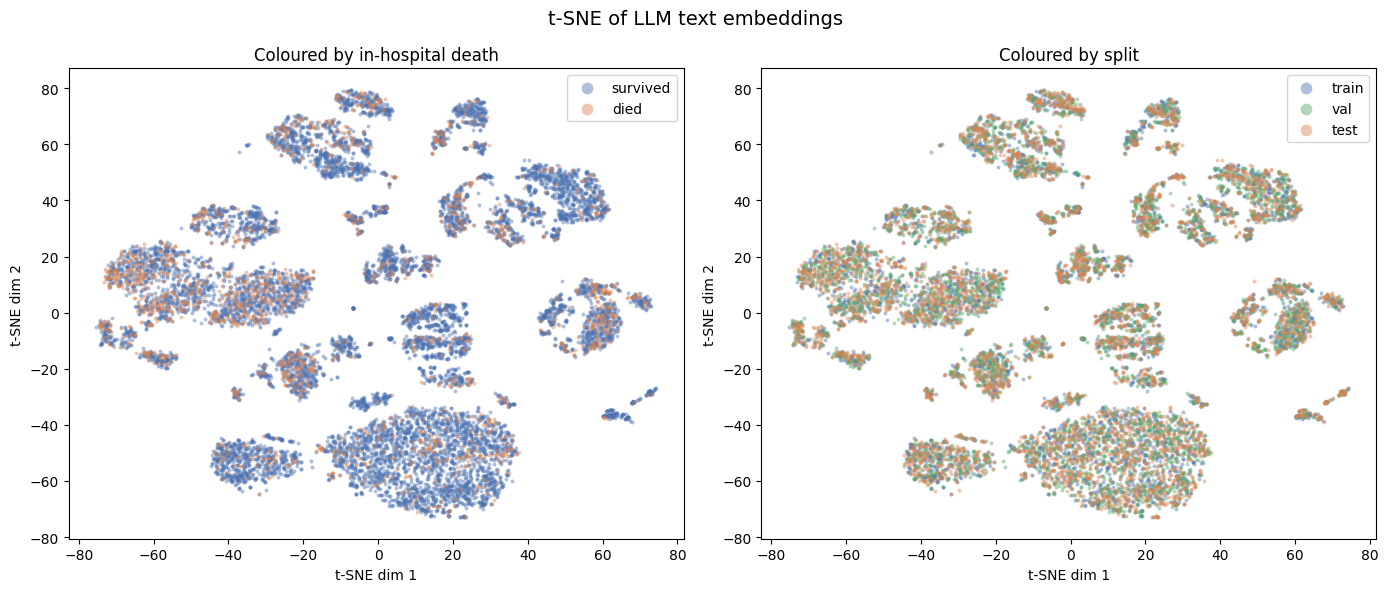

In [32]:
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE


emb_all   = np.vstack([emb_train, emb_val, emb_test])
lbl_all   = np.concatenate([lbl_train, lbl_val, lbl_test])
split_all = np.array(
    ['train'] * len(lbl_train) +
    ['val']   * len(lbl_val)   +
    ['test']  * len(lbl_test)
)
split_colors = {'train': '#4c72b0', 'val': '#55a868', 'test': '#dd8452'}

tsne      = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
emb2_tsne = tsne.fit_transform(sk_normalize(emb_all, norm='l2'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('t-SNE of LLM text embeddings', fontsize=14)

ax = axes[0]
for lbl, name, c in [(0, 'survived', '#4c72b0'), (1, 'died', '#dd8452')]:
    mask = lbl_all == lbl
    ax.scatter(emb2_tsne[mask, 0], emb2_tsne[mask, 1],
               c=c, label=name, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by in-hospital death')
ax.legend(markerscale=3)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

ax = axes[1]
for sp, c in split_colors.items():
    mask = split_all == sp
    ax.scatter(emb2_tsne[mask, 0], emb2_tsne[mask, 1],
               c=c, label=sp, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by split')
ax.legend(markerscale=3)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

plt.tight_layout(); plt.show()

## 13 — UMAP of LLM embeddings

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


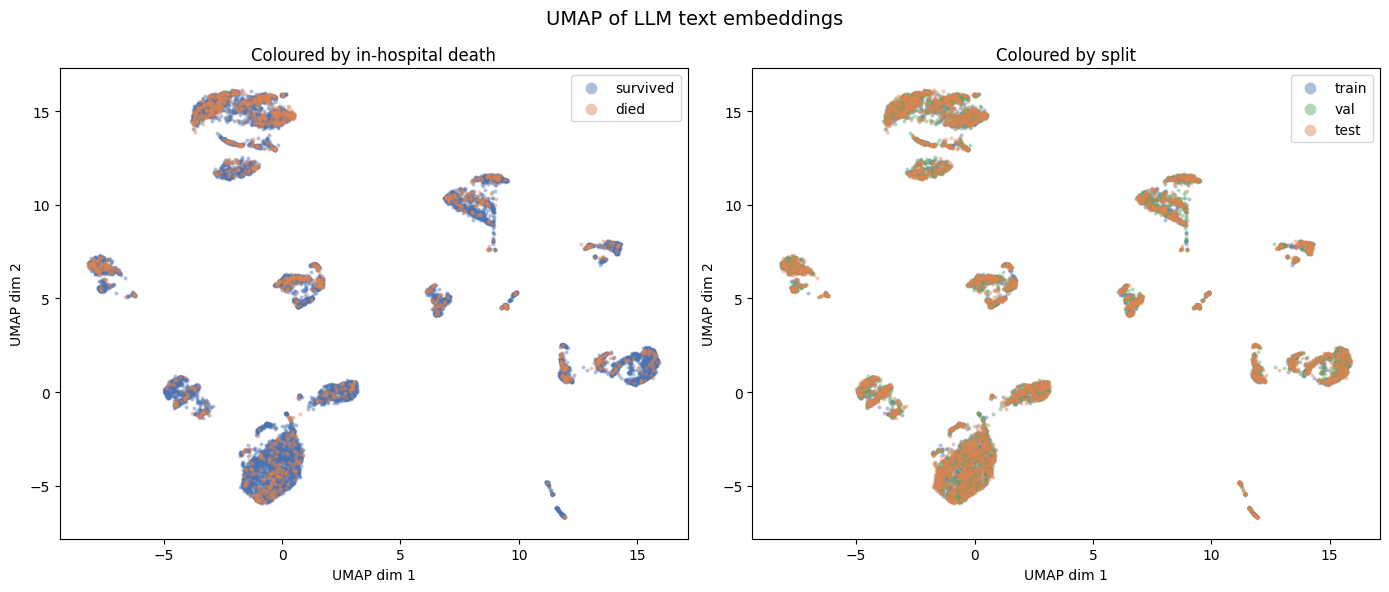

In [33]:
import umap


reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
emb2_umap = reducer.fit_transform(sk_normalize(emb_all, norm='l2'))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('UMAP of LLM text embeddings', fontsize=14)

ax = axes[0]
for lbl, name, c in [(0, 'survived', '#4c72b0'), (1, 'died', '#dd8452')]:
    mask = lbl_all == lbl
    ax.scatter(emb2_umap[mask, 0], emb2_umap[mask, 1],
               c=c, label=name, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by in-hospital death')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')

ax = axes[1]
for sp, c in split_colors.items():
    mask = split_all == sp
    ax.scatter(emb2_umap[mask, 0], emb2_umap[mask, 1],
               c=c, label=sp, alpha=0.45, s=8, linewidths=0)
ax.set_title('Coloured by split')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP dim 1'); ax.set_ylabel('UMAP dim 2')

plt.tight_layout(); plt.show()

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize as sk_normalize


emb_norm = sk_normalize(emb_all, norm='l2')
sil_cos = silhouette_score(emb_norm, lbl_all, metric='euclidean')
sil_umap = silhouette_score(emb2_umap, lbl_all, metric='euclidean')

km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(emb_all)
nmi = normalized_mutual_info_score(lbl_all, km_labels)
ari = adjusted_rand_score(lbl_all, km_labels)

print(f'Silhouette (cosine, raw emb):       {sil_cos:.4f}')
print(f'Silhouette (euclidean, UMAP 2-d):   {sil_umap:.4f}')
print(f'NMI  (k-Means k=2 vs labels):       {nmi:.4f}')
print(f'ARI  (k-Means k=2 vs labels):       {ari:.4f}')

Silhouette (cosine, raw emb):       -0.0181
Silhouette (euclidean, UMAP 2-d):   0.0191
NMI  (k-Means k=2 vs labels):       0.0007
ARI  (k-Means k=2 vs labels):       -0.0017
